# 03 - Heatmaps And Report Artifact Explorer

This notebook recreates compact versions of the interaction heatmaps in `docs/reports/metric_analysis/thorough/metric_analysis.tex` and inspects the generated report artifacts.

Use small grids while exploring. Increase the grid size only when you need report-quality detail.

In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
import json

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable

def find_repo_dir(start: Path) -> Path:
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "configs" / "baseline.yaml").exists() and (
            candidate / "simulation" / "config_loader.py"
        ).exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current notebook location.")

REPO_DIR = find_repo_dir(Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from analysis.metrics import result_metrics_from_result
import analysis.plot_style as plot_style

plot_style = importlib.reload(plot_style)
driver_heatmap_cmap = plot_style.driver_heatmap_cmap
DRIVER_GAP_ENDPOINTS = plot_style.DRIVER_GAP_ENDPOINTS
from simulation.config_loader import load_config
from simulation.engine import ClinicAppointmentSimulation
from simulation.model import ThresholdRule

BASE_CONFIG = load_config(REPO_DIR / "configs" / "baseline.yaml")
pd.options.display.max_columns = 120


## Heatmap Helper

The plotting helper is reused below; the scenario changes stay inline in each grid cell.


In [2]:
def draw_heatmap(df, x_name, y_name, metric, title, driver, diverging=False):
    table = df.pivot(index=y_name, columns=x_name, values=metric).sort_index().sort_index(axis=1)
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = driver_heatmap_cmap(driver, diverging=diverging)
    norm = None
    if diverging:
        max_abs = float(np.nanmax(np.abs(table.values)))
        norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs) if max_abs else None
    image = ax.imshow(table.values, origin="lower", aspect="auto", cmap=cmap, norm=norm)
    ax.set_title(title)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels([f"{v:.2g}" for v in table.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels([f"{v:.2g}" for v in table.index])
    colorbar = fig.colorbar(image, ax=ax, shrink=0.85)
    if diverging:
        colorbar.set_label("Class 1 - Class 2")
    fig.tight_layout()
    return fig


## Balking Step Interaction

This compact grid mirrors the report's balking-step heatmaps.

Balking step grid (class 1):   0%|          | 0/11 [00:00<?, ?it/s]

Balking step grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Balking step grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Balking step grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Balking step grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

...

Balking step grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Balking step grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Balking step grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Balking step grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

,class_1_balk_step,class_2_balk_step,average_utilization,overall_percent_serviced,mean_accepted_booking_delay,mean_offered_booking_delay,class_1_percent_serviced,class_2_percent_serviced,overall_balking_rate,class_1_balking_rate,class_2_balking_rate,class_1_slot_utilization,class_2_slot_utilization,class_1_mean_offered_booking_delay,class_2_mean_offered_booking_delay,access_advantage_class_1,balking_rate_gap_class_1,delay_advantage_class_1
0,0.0,0.0,0.839983,0.266074,9.455949,9.455949,0.265105,0.267039,0.000000,0.0,0.000000,0.416610,0.422003,9.467413,9.444488,-0.001934,0.000000,-0.022926
1,0.0,0.1,0.836130,0.265059,9.468103,9.567604,0.270522,0.259562,0.032320,0.0,0.065051,0.427740,0.407877,9.560108,9.575196,0.010960,-0.065051,0.015088
2,0.0,0.2,0.842979,0.269317,9.461352,9.644081,0.275754,0.262931,0.059320,0.0,0.117763,0.429709,0.413014,9.660260,9.628141,0.012823,-0.117763,-0.032119
3,0.0,0.3,0.842551,0.268792,9.462451,9.744494,0.284354,0.253160,0.091060,0.0,0.183163,0.445034,0.394435,9.724921,9.764292,0.031195,-0.183163,0.039371
4,0.0,0.4,0.842295,0.269737,9.422320,9.829819,0.288214,0.251397,0.130971,0.0,0.260922,0.447003,0.392808,9.866013,9.793906,0.036817,-0.260922,-0.072106


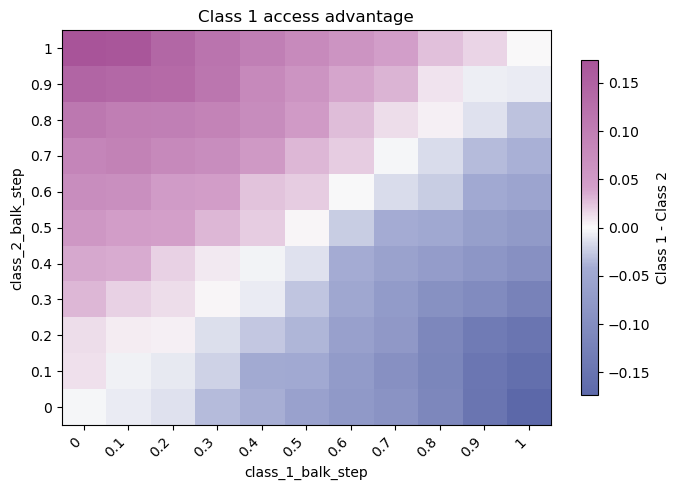

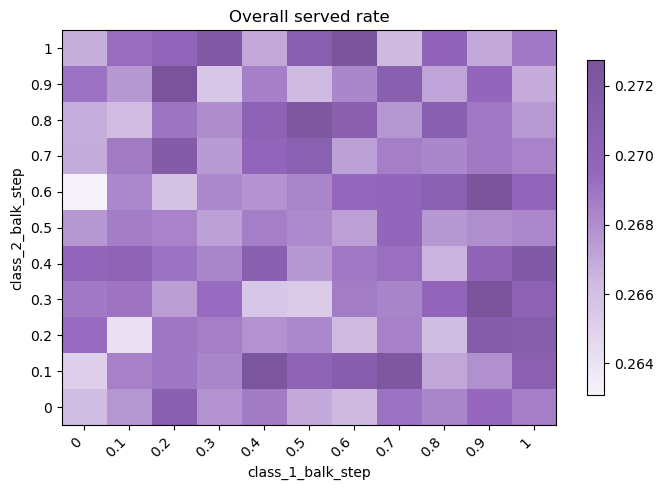

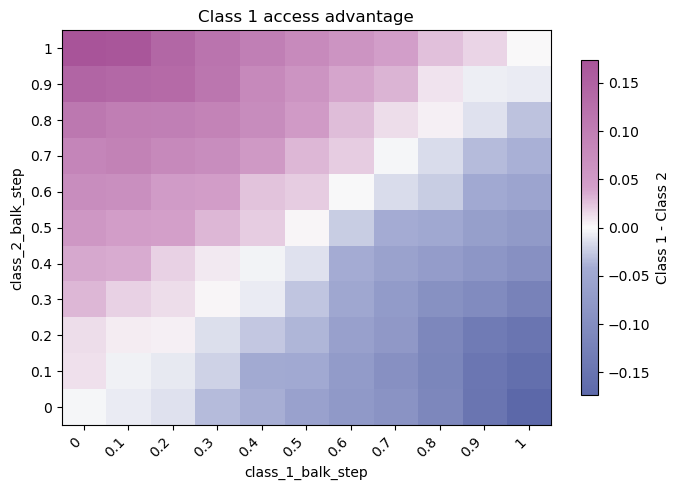

In [3]:
STEP_VALUES = np.linspace(0.0, 1.0, 11)
base_balk_rules = {
    class_id: params.balk_prob
    for class_id, params in BASE_CONFIG.classes.items()
}

rows = []
for class_1_step in tqdm(STEP_VALUES, desc="Balking step grid (class 1)"):
    for class_2_step in tqdm(STEP_VALUES, desc="Balking step grid (class 2)", leave=False):
        class_1_rule = base_balk_rules[1]
        class_2_rule = base_balk_rules[2]
        classes = {
            **BASE_CONFIG.classes,
            1: replace(
                BASE_CONFIG.classes[1],
                balk_prob=ThresholdRule(
                    threshold=class_1_rule.threshold,
                    low=class_1_rule.low,
                    high=min(class_1_rule.low + float(class_1_step), 1.0),
                ),
            ),
            2: replace(
                BASE_CONFIG.classes[2],
                balk_prob=ThresholdRule(
                    threshold=class_2_rule.threshold,
                    low=class_2_rule.low,
                    high=min(class_2_rule.low + float(class_2_step), 1.0),
                ),
            ),
        }
        config = replace(BASE_CONFIG, classes=classes, seed=2027)
        result = ClinicAppointmentSimulation(config).run()
        rows.append(
            {
                "class_1_balk_step": class_1_step,
                "class_2_balk_step": class_2_step,
                **result_metrics_from_result(result),
            }
        )

balk_grid = pd.DataFrame(rows)
display(balk_grid.head())

draw_heatmap(balk_grid, "class_1_balk_step", "class_2_balk_step", "overall_percent_serviced", "Overall served rate", "balking")
draw_heatmap(balk_grid, "class_1_balk_step", "class_2_balk_step", "access_advantage_class_1", "Class 1 access advantage", "balking", diverging=True)


## Cancellation Interaction

Cancellation has one of the strongest class-gap effects in the report.

Cancellation grid (class 1):   0%|          | 0/11 [00:00<?, ?it/s]

Cancellation grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Cancellation grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Cancellation grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Cancellation grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

...

Cancellation grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Cancellation grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Cancellation grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Cancellation grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

Cancellation grid (class 2):   0%|          | 0/11 [00:00<?, ?it/s]

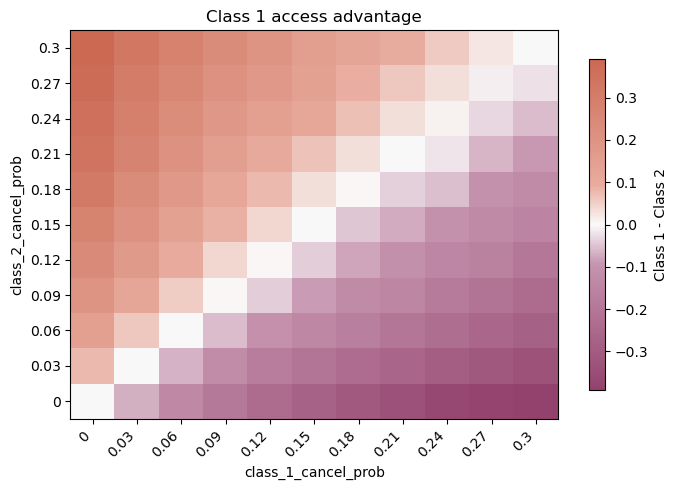

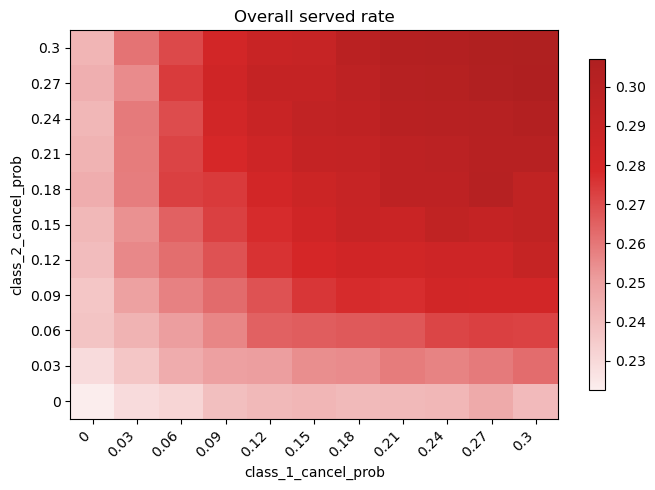

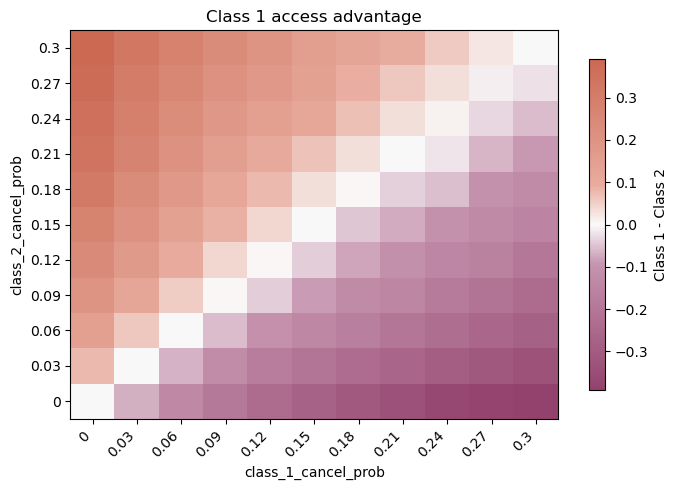

In [4]:
CANCEL_VALUES = np.linspace(0.0, 0.30, 11)

rows = []
for class_1_cancel in tqdm(CANCEL_VALUES, desc="Cancellation grid (class 1)"):
    for class_2_cancel in tqdm(CANCEL_VALUES, desc="Cancellation grid (class 2)", leave=False):
        classes = {
            **BASE_CONFIG.classes,
            1: replace(BASE_CONFIG.classes[1], cancel_prob=float(class_1_cancel)),
            2: replace(BASE_CONFIG.classes[2], cancel_prob=float(class_2_cancel)),
        }
        config = replace(BASE_CONFIG, classes=classes, seed=2027)
        result = ClinicAppointmentSimulation(config).run()
        rows.append(
            {
                "class_1_cancel_prob": class_1_cancel,
                "class_2_cancel_prob": class_2_cancel,
                **result_metrics_from_result(result),
            }
        )

cancel_grid = pd.DataFrame(rows)

draw_heatmap(cancel_grid, "class_1_cancel_prob", "class_2_cancel_prob", "overall_percent_serviced", "Overall served rate", "cancellation")
draw_heatmap(cancel_grid, "class_1_cancel_prob", "class_2_cancel_prob", "access_advantage_class_1", "Class 1 access advantage", "cancellation", diverging=True)


## Inspect Generated Report Artifacts

The manifest is written by `scripts/generate_metric_analysis_figures.py` and records the command, config hashes, package versions, seeds, grids, row counts, and artifacts generated in that run.

In [5]:
manifest_path = REPO_DIR / "outputs" / "reports" / "metric_analysis" / "manifest.json"
manifest = json.loads(manifest_path.read_text())

print("command:", " ".join(manifest["command"]))
print("git:", manifest["git"])
print("generated artifacts:", len(manifest["generated_artifacts"]))

display(pd.Series(manifest["row_counts"], name="rows").to_frame())
display(pd.Series(manifest["environment"]["packages"], name="version").to_frame())

command: python scripts/generate_metric_analysis_figures.py
git: {'commit': '6aa48fbba28e856585df823fa0b9e2f5cbcfca9c', 'dirty': True}
generated artifacts: 65


,rows
arrival_mix_grid,187
balking_class1_step_slice,21
balking_class1_threshold_slice,14
balking_step_grid,441
balking_threshold_grid,196
balking_threshold_jump_grid,294
cancellation_grid,441
class_arrival_grid,42
fcfs_capacity_stress,15
no_show_step_grid,441


,version
jupyter,1.1.1
matplotlib,3.10.0
numpy,1.26.4
pandas,2.2.3
pyyaml,6.0.2


## Open Existing Report Figures

Use this cell to inspect any generated figure without leaving the notebook.
Change `figure_name` to another file listed in the manifest.

/Users/alexandresepulvedadedietrich/CUIMC-Appointment-Simulation/docs/reports/metric_analysis/figures/metric_access_drivers.png


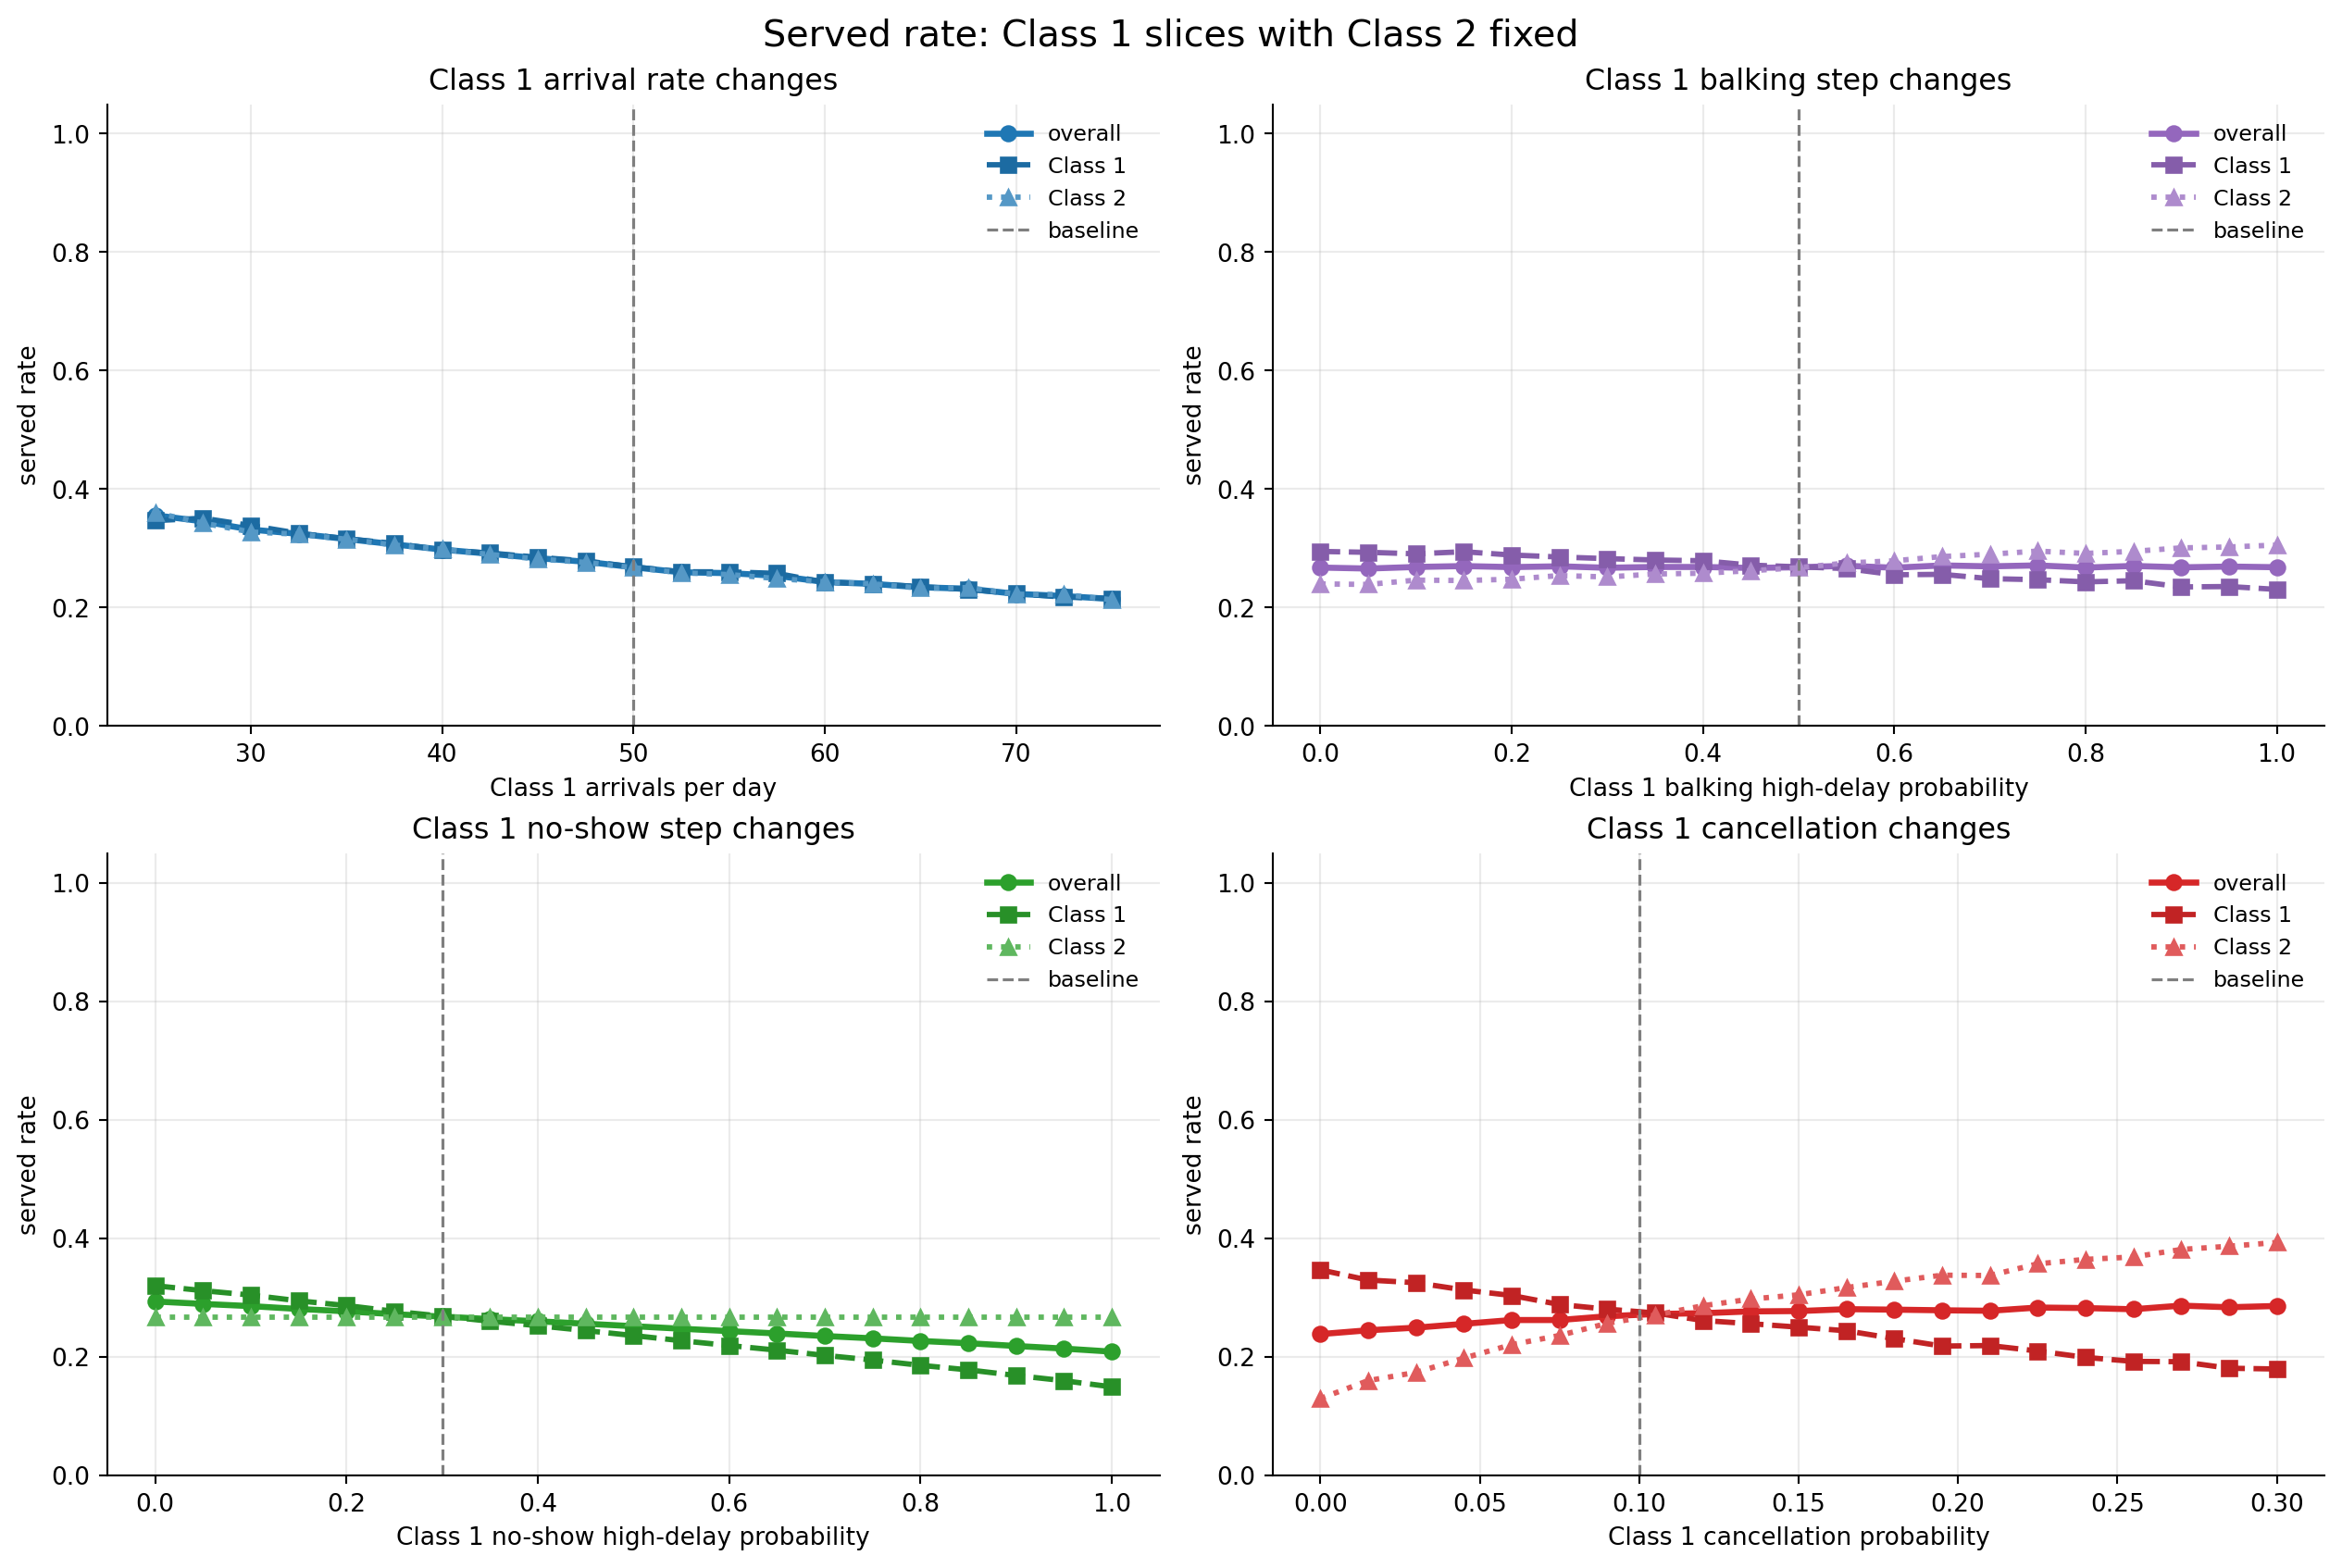

In [6]:
from IPython.display import Image, display

figure_name = "metric_access_drivers.png"
figure_path = REPO_DIR / "outputs" / "reports" / "metric_analysis" / "figures" / figure_name
print(figure_path)
display(Image(filename=str(figure_path)))